# **European Drugs Development**

Team 10: Chamnan Suon

## **Executive Summary**

One of the two primary areas in our previous milestones discussed the influence of regulatory pathways on medicine authorization outcomes. This aligns with the domain question in Milestone2 on the association of regulatory pathways with medicine refusal outcome. Milestone4 will dive deeper into this area by expanding the regulatory pathway analysis and therapeutic_area analysis associated with the refusal outcome. Specifically, an additional feature revision_number is introduced to analyze further how regulatory pathways influence the refusal outcome. These extended analyses will help anchoring the domain question by answering subquestion such as how higher medicine revision number combined with regulatory pathways associated with refusal outcome? and is the refusal outcome structurally tied to the therapeutic domain than the pathways?
Previously, two assumptions were made and validated: the first assumption on regulatory features that were found to act together, proving the first assumption to be insufficient. Second assumption hovers around company behavior linked to refusal outcome, this assumption as well found to be invalidated as association rule mining analysis shows that refusal outcome strongly links to regulator pathway characteristics.
By performing a deeper analysis, I hope more interesting new insights will emerge which would help companies refine their strategies and improve the development process, ultimately increasing the likelihood of approved medicine. Additionally, this also helps with cost effectiveness as they would be able to focus on the areas that actually matter.


## **Data Dictionary**

 `drugs_dataset.csv`

|Column  |Class      |Description          |
|:-------|:----------|:--------------------|
|category|character | human or veterinary|
|medicine_name | character | brand name of the medicine|
|therapeutic_area | character | semicolon-separated list of therapeutic areas|
|common_name | character | international non-proprietary name (INN) or common name|
|active_substance | character | common name of the active chemical in the drug|
|product_number | character | EMEA/H/C/ (human) or EMEA/V/C/ (veterinary) number for the drug|
|patient_safety | logical | has patient safety notices|
|authorisation_status | character | whether the drug was authorised, withdrawn, or refused (or does not have a reported status)|
|atc_code | character | anatomical therapeutic chemical code|
|additional_monitoring | logical | when true, the medicine is under additional monitoring, meaning that it is monitored even more intensively than other medicines|
|generic | logical | whether the drug is a generic medicine, which is developed to be the same as a medicine that has already been authorised, called the reference medicine. A generic medicine contains the same active substance(s) as the reference medicine, and is used at the same dose(s) to treat the same disease(s)|
|biosimilar | logical | whether the drug is a biosimilar medicine, which is a biological medicine highly similar to another already approved biological medicine called the reference medicine.|
|conditional_approval | logical | whether the medicine received a conditional marketing authorisation. This was granted in the interest of public health because the medicine addresses an unmet medical need and the benefit of immediate availability outweighs the risk from less comprehensive data than normally required.|
|exceptional_circumstances | logical | whether the medicine was authorised under exceptional circumstances, because the applicant was unable to provide comprehensive data on the efficacy and safety of the medicine under normal conditions of use. This can happen because the condition to be treated is rare or because collection of full information is not possible or is unethical.|
|accelerated_assessment | logical | whether the medicine had an accelerated assessment. This means that it is a medicine of major interest for public health, so its timeframe for review was 150 evaluation days rather than 210.|
|orphan_medicine | logical | whether the medicine was designated an orphan medicine. This means that it was developed for use against a rare, life-threatening or chronically debilitating condition or, for economic reasons, it would be unlikely to have been developed without incentives.|
|marketing_authorisation_date | date | date on which the drug was authorised|
|date_of_refusal_of_marketing_authorisation | date | date on which the drug was refused|
|marketing_authorisation_holder_company_name | character | name of the company that is authorised to market the drug|
|pharmacotherapeutic_group | character | the target of the drug|
|date_of_opinion | date | date on which the opinion was made|
|decision_date | date | date on which the latest decision was made|
|revision_number | integer | integer revision number|
|condition_indication | character | language describing the specific uses of the drug|
|species | character | for veterinary medicines, the target species; might benefit from further cleaning|
|first_published | datetime | datetime when the information was first published|
|revision_date | datetime | datetime of the most recent revision|
|url | character | url for details about the drug and submission|

## **Data Cleaning and Preprocessing**

In [ ]:
# Import pandas and numpy for DataFrame and operations
import pandas as pd
import numpy as np
import warnings

# Filter out DeprecationWarning for specific modules
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')
warnings.filterwarnings("ignore", category=DeprecationWarning, module='matplotlib')
warnings.filterwarnings("ignore", category=DeprecationWarning, module='pyparsing')

print("Deprecation warnings are now suppressed.")

Deprecation warnings are now suppressed.


In [ ]:
# Load dataset from github relative path
path = "https://raw.githubusercontent.com/SChamnan/ba820-unsupervised-ml-team10-project/refs/heads/main/european-drugs-development/drugs-dataset.csv"
drugs_df = pd.read_csv(path)
drugs_original=drugs_df.copy()
# Check out the first 5 rows of data
drugs_df.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


### **Data Cleaning and Preprocessing**

In [ ]:
# Check number of rows and columns
drugs_df.shape

(1988, 28)

In [ ]:
drugs_df.describe()

,product_number,revision_number
count,1988.000000,1892.000000
mean,2634.774145,13.527484
std,1915.734686,11.647056
min,24.000000,0.000000
25%,715.750000,4.750000
50%,2544.500000,11.000000
75%,4351.000000,19.000000
max,6039.000000,89.000000


Below shows number of missing values in each column. These missing values could be either removed or keep as they are. Imputation may not be the best option as it may misrepresenting data.

In [ ]:
# Chart showing missing values of each column
missing_values = drugs_df.isnull().sum()
missing_percentage = ((drugs_df.isnull().sum() / len(drugs_df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
date_of_refusal_of_marketing_authorisation,1913,96.23
species,1709,85.97
date_of_opinion,779,39.19
therapeutic_area,285,14.34
revision_number,96,4.83
marketing_authorisation_date,60,3.02
decision_date,45,2.26
pharmacotherapeutic_group,34,1.71
revision_date,29,1.46
atc_code,28,1.41


In [ ]:
# Information of values of the variable 'species'
unique_species_with_nan = drugs_df['species'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'species' column:")
print(unique_species_with_nan)


Unique values and their counts (including NaN) in 'species' column:
species
NaN                                                                    1709
Dogs                                                                     70
Cats                                                                     28
Pigs                                                                     25
Dogs; Cats                                                               18
Horses                                                                   18
Chicken                                                                  15
Cattle                                                                   10
Cattle; Pigs; Sheep                                                       7
Sheep; Cattle                                                             6
Cats; Dogs                                                                5
Sheep                                                                     5
Rabbits    

In [ ]:
# Get the count of all unique values, including NaN, for 'authorisation_status'
unique_auth_status_with_nan = drugs_df['authorisation_status'].value_counts(dropna=False)
print("Unique values and their counts (including NaN) in 'authorisation_status' column:")
print(unique_auth_status_with_nan)

# You can apply the same to other columns as needed, for example 'category'
unique_category_with_nan = drugs_df['category'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'category' column:")
print(unique_category_with_nan)

Unique values and their counts (including NaN) in 'authorisation_status' column:
authorisation_status
authorised    1573
withdrawn      357
refused         57
NaN              1
Name: count, dtype: int64

Unique values and their counts (including NaN) in 'category' column:
category
human         1706
veterinary     282
Name: count, dtype: int64


### **Categorization of the Columns**

In [ ]:
# Categorize columns type
# Category cols
cat_cols = ["category",
            "medicine_name",
            "common_name",
            "active_substance",
            "authorisation_status",
            "atc_code",
            "marketing_authorisation_holder_company_name"]

#text cols
text_cols = ["condition_indication"]

# id cols
id_cols = ["url", "product_number"]

# list text cols
list_text_cols = ["therapeutic_area",
                  "pharmacotherapeutic_group",
                  "species"]

# Numeric cols
numeric_cols = ["revision_number"]

# Boolean cols
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]

# Datetime cols
datetime_cols = ["marketing_authorisation_date",
             "date_of_refusal_of_marketing_authorisation",
             "date_of_opinion",
             "decision_date",
             "revision_date",
             "first_published"]


### **Preparing data for Analysis**

In [ ]:

def clean_string_series(s):
    """
    Standard string cleanup:
    - converts to pandas 'string' dtype
    - normalizes whitespace (multiple spaces -> one)
    - trims leading/trailing whitespace
    """
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def to_bool_series(s):
    """
    Robust boolean conversion:
    Handles columns that might be stored as:
    - True/False
    - 1/0
    - 'TRUE'/'FALSE'
    - 'Yes'/'No'
    Missing values are treated as False (safe default for these regulatory flags).
    """
    if s.dtype == bool:
        return s.fillna(False)

    s_str = s.astype("string")
    s_norm = s_str.str.strip().str.lower()

    true_set = {"true", "t", "1", "yes", "y"}
    false_set = {"false", "f", "0", "no", "n", ""}

    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out = out.mask(s_norm.isin(true_set), True)
    out = out.mask(s_norm.isin(false_set), False)

    # fallback numeric coercion for any remaining NAs
    if out.isna().any():
        num = pd.to_numeric(s_str, errors="coerce")
        out = out.fillna(num.eq(1))

    return out.fillna(False).astype(bool)

def clean_list_text_column(s):
    """
    Cleanup for semicolon-separated list fields like:
    therapeutic_area, pharmacotherapeutic_group, species.
    - normalizes whitespace
    - standardizes delimiter spacing: "A;B" -> "A; B"
    """
    s = clean_string_series(s)
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

def clean_species_column(s):
    """
    Extra cleanup for species:
    - removes parenthetical qualifiers: 'Pigs (for fattening)' -> 'Pigs'
    - standardizes semicolon spacing: 'Dogs;Cats' -> 'Dogs; Cats'
    """
    s = clean_list_text_column(s)
    s = s.str.replace(r"\s*\(.*?\)\s*", "", regex=True).str.strip()
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

**clean_string_series(s)**
This function cleans a text column in a consistent way. It converts the column to a string type, replaces multiple spaces with a single space, and removes extra spaces at the beginning and end of each value. This helps avoid errors caused by inconsistent spacing.

**to_bool_series(s)**
This function converts a column into True/False values even if the column is stored in different formats. It can handle values like True/False, 1/0, and text like "yes"/"no" or "true"/"false". Missing values are treated as False to keep regulatory flag columns safe and consistent for later analysis.

**clean_list_text_column(s)**
This function cleans columns that contain lists stored as text using semicolons (for example: "A;B"). It first applies basic text cleaning (spacing and trimming). Then it standardizes the semicolon format so items are separated as "; " (semicolon + one space). This makes splitting the list later more reliable.

**clean_species_column(s)**
This function is a specialized cleaner for the species column. It applies the semicolon list cleaning, removes extra text written inside parentheses (for example: "Pigs (for fattening)" becomes "Pigs"), and standardizes semicolon spacing again. This produces a cleaner and more consistent species field for later grouping and analysis.

### **Cleaning & Type casting columns**

In [ ]:
drugs_df = drugs_df.copy()

# Clean category/text/id columns (trim + normalize spacing)
for c in (cat_cols + text_cols + id_cols):
    if c in drugs_df.columns:
        drugs_df[c] = clean_string_series(drugs_df[c])

# Clean list-text columns
for c in list_text_cols:
    if c in drugs_df.columns:
        if c == "species":
            drugs_df[c] = clean_species_column(drugs_df[c])
        else:
            drugs_df[c] = clean_list_text_column(drugs_df[c])

# Standardize small categorical fields
if "category" in drugs_df.columns:
    drugs_df["category"] = drugs_df["category"].astype("string").str.lower().str.strip()

if "authorisation_status" in drugs_df.columns:
    drugs_df["authorisation_status"] = drugs_df["authorisation_status"].astype("string").str.lower().str.strip()

if "atc_code" in drugs_df.columns:
    drugs_df["atc_code"] = drugs_df["atc_code"].astype("string").str.upper().str.strip()

# Cast booleans group
for c in boolean_cols:
    if c in drugs_df.columns:
        drugs_df[c] = to_bool_series(drugs_df[c])


# Cast numeric group
for c in numeric_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_numeric(drugs_df[c], errors="coerce").astype("Int64")


# Cast datetimes group
for c in datetime_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_datetime(drugs_df[c], errors="coerce")


# Quick checks
print("Category counts:\n", drugs_df["category"].value_counts(dropna=False), "\n")
print("Status counts:\n", drugs_df["authorisation_status"].value_counts(dropna=False), "\n")
if "species" in drugs_df.columns:
    print("Top species values:\n", drugs_df["species"].value_counts(dropna=False).head(10))


Category counts:
 category
human         1706
veterinary     282
Name: count, dtype: Int64 

Status counts:
 authorisation_status
authorised    1573
withdrawn      357
refused         57
<NA>             1
Name: count, dtype: Int64 

Top species values:
 species
<NA>                   1709
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: Int64


**Clean category/text/id columns**
Since text fields can include extra spaces or inconsistent spacing, we clean these columns by standardizing whitespace and trimming leading and trailing spaces.

**Clean list-text columns**
Since some fields store multiple values in one cell using semicolons, we standardize the formatting of these list-style columns so they are consistent. For species, we also remove text inside parentheses to keep the names clean.

**Standardize small categorical fields**
Since category and authorisation_status may appear with different capitalization or spaces, we convert them to lowercase and trim spaces. Since atc_code should follow a consistent code format, we convert it to uppercase and trim spaces.

**Cast columns (booleans, numeric, and datetime)**
Since some columns may be stored with inconsistent data types (for example, booleans as text, numbers as strings, or dates in mixed formats), we convert boolean, numeric, and datetime columns into consistent types. Any values that cannot be converted are set to missing to avoid errors in later analysis.

**Quick checks**
Since we want to confirm the cleaning worked, we print basic value counts for category, authorisation_status, and the most common species values.

### **Data Overview After Cleaning**

In [ ]:
# show size, missingness, imbalance, and what fields are “strong enough” to analyze.
# Shape
print("Rows, Columns:", drugs_df.shape)

# Missingness table (top missing)
missing = drugs_df.isna().mean().sort_values(ascending=False).to_frame("missing_pct")
missing["missing_pct"] = (missing["missing_pct"] * 100).round(2)
print(missing.head(15))

# Uniqueness checks
print("Unique product_number:", drugs_df["product_number"].nunique(dropna=False))
print("Unique url:", drugs_df["url"].nunique(dropna=False))

Rows, Columns: (1988, 28)
                                             missing_pct
date_of_refusal_of_marketing_authorisation         96.23
species                                            85.97
date_of_opinion                                    39.19
therapeutic_area                                   14.34
revision_number                                     4.83
marketing_authorisation_date                        3.02
decision_date                                       2.26
pharmacotherapeutic_group                           1.71
revision_date                                       1.46
atc_code                                            1.41
condition_indication                                0.60
common_name                                         0.20
marketing_authorisation_holder_company_name         0.20
active_substance                                    0.05
authorisation_status                                0.05
Unique product_number: 1932
Unique url: 1988


In [ ]:
drugs_df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34,Hodgkin lymphomaAdcetris is indicated for adul...,<NA>,2018-07-25 13:58:00+00:00,2023-03-13 11:52:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4,Treatment of adult and paediatric patients wit...,<NA>,2018-07-26 14:20:00+00:00,2023-03-10 17:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,Pierre Fabre Medicament,<NA>,2022-10-13,2023-03-09,2,Ebvallo is indicated as monotherapy for treatm...,<NA>,2022-10-12 16:13:00+00:00,2023-03-10 13:40:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3,Ronapreve is indicated for:Treatment of COVID-...,<NA>,2021-11-12 16:30:00+00:00,2023-03-10 12:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30,Plaque psoriasisCosentyx is indicated for the ...,<NA>,2018-06-07 11:59:00+00:00,2023-03-09 18:53:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...


Dataset is cleaned and is ready for next steps.

## **Exploratory Data Analysis**

### **Top therapeutic area by number of refused medicines**

Viewing list of top 10 companies with the most authorized medicines.

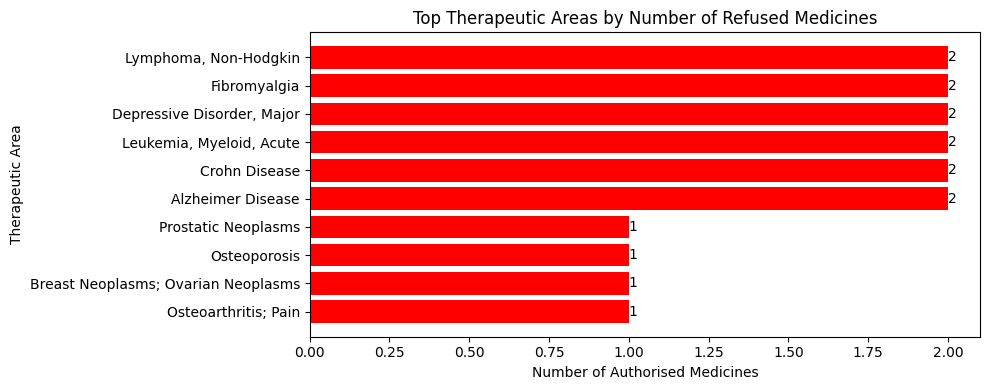

In [ ]:
import matplotlib.pyplot as plt
# Filter to get only authorized medicines
authorised_df = drugs_df[drugs_df["authorisation_status"] == "refused"].copy()

therapeutic_counts = (
authorised_df.explode("therapeutic_area")["therapeutic_area"]
.dropna()
.value_counts()
.head(10)
.sort_values()
)

# Plot bar graph
plt.figure(figsize=(10, 4))
plt.barh(therapeutic_counts.index, therapeutic_counts.values, color='red')

# Add number on each bar for better readability
for i, v in enumerate(therapeutic_counts.values):
    plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Therapeutic Area")
plt.title("Top Therapeutic Areas by Number of Refused Medicines")
plt.tight_layout()
plt.show()

### **Top Therapeutic areas by number of authorized medicines**

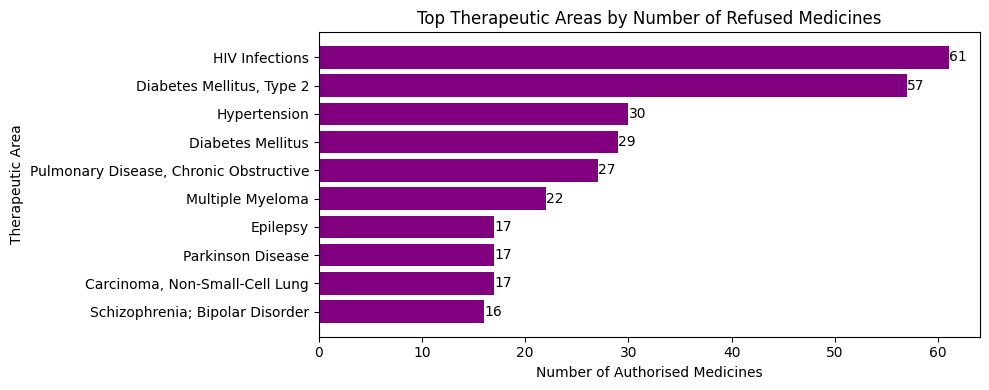

In [ ]:
# Filter to get only authorized medicines
#authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()
authorised_df = drugs_df[drugs_df["authorisation_status"] == "authorised"].copy()

therapeutic_counts = (
authorised_df.explode("therapeutic_area")["therapeutic_area"]
.dropna()
.value_counts()
.head(10)
.sort_values()
)

# Plot bar graph
plt.figure(figsize=(10, 4))
plt.barh(therapeutic_counts.index, therapeutic_counts.values, color='purple')

# Add number on each bar for better readability
for i, v in enumerate(therapeutic_counts.values):
    plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Therapeutic Area")
plt.title("Top Therapeutic Areas by Number of Refused Medicines")
plt.tight_layout()
plt.show()

### **Refused Medicines Over Time**

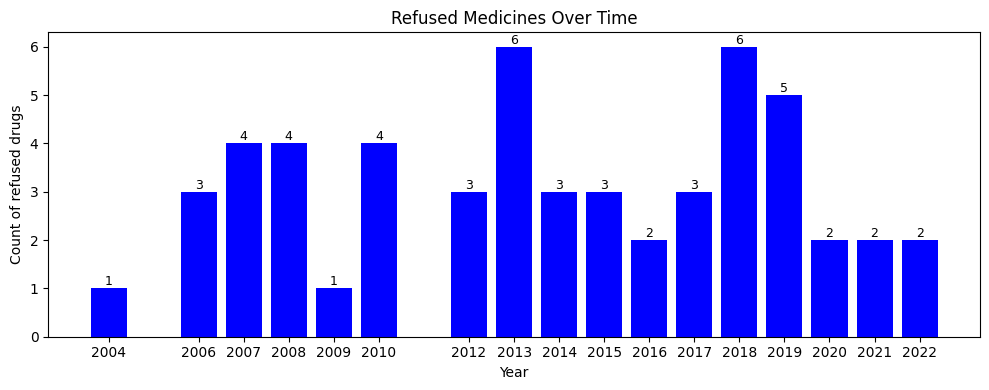

In [ ]:
# Graph showing count of refused medicines over time
refused_df = drugs_df[drugs_df["authorisation_status"]=="refused"].copy() # Authorisation = refused
refused_df["refused_year"] = refused_df["date_of_refusal_of_marketing_authorisation"].dt.year
refused_count = refused_df["refused_year"].value_counts().sort_index()
plt.figure(figsize=(10,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='blue')
# Adding data labels
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )
plt.title("Refused Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

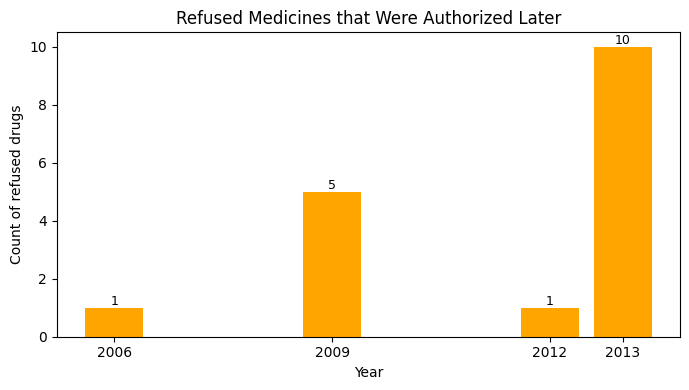

In [ ]:
# Graph showing count of refused medicines that got approved later
refused_df2 = drugs_df[
    drugs_df["date_of_refusal_of_marketing_authorisation"].notna()&
    (drugs_df["authorisation_status"].str.lower()=="authorised")
].copy()
refused_df2["refused_year"] = refused_df2["date_of_refusal_of_marketing_authorisation"].dt.year
refused_count = refused_df2["refused_year"].value_counts().sort_index()
plt.figure(figsize=(7,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='orange')

# Adding data labels
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )
plt.title("Refused Medicines that Were Authorized Later")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

### **Distribution of Revision Number**

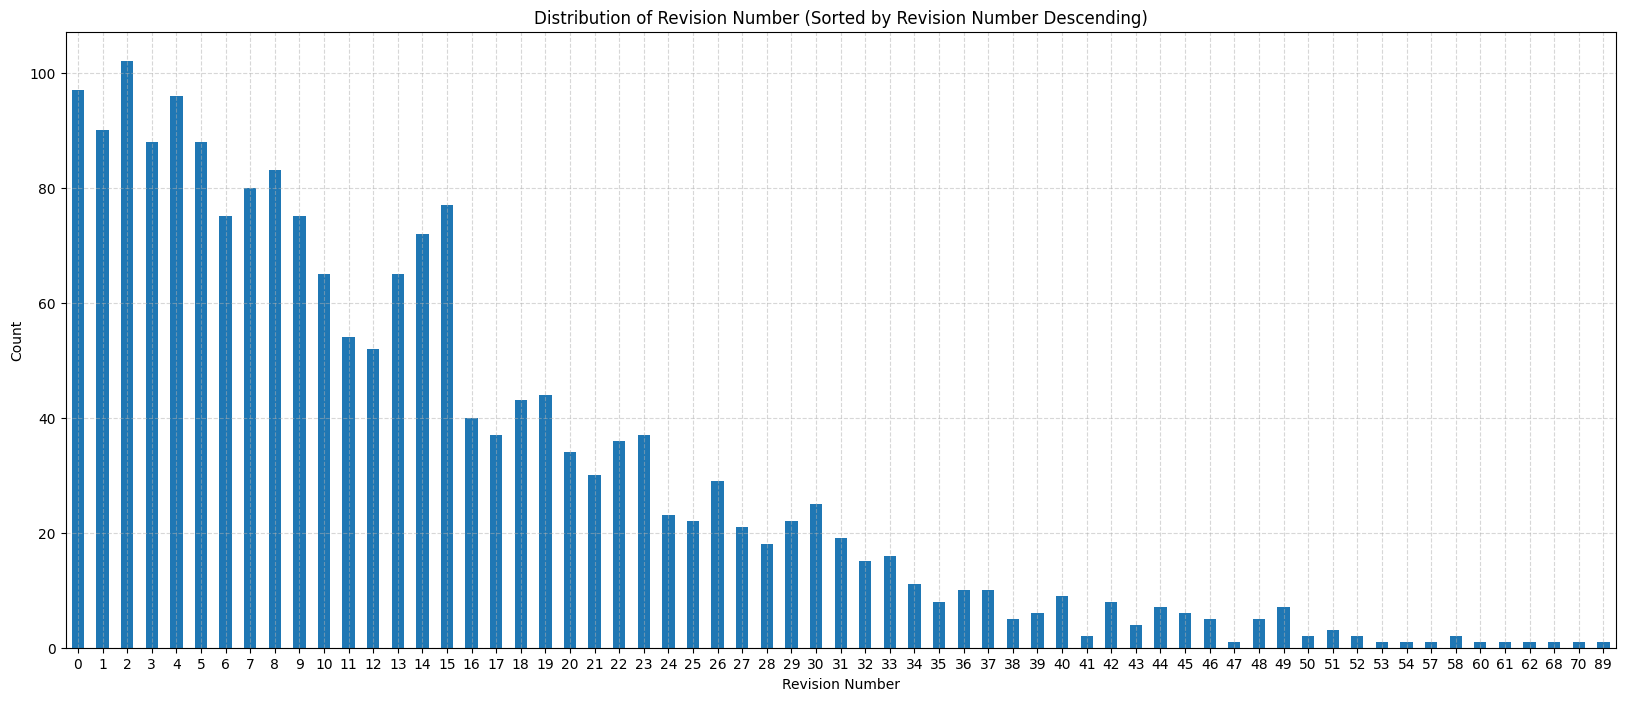

In [ ]:
counts = drugs_df["revision_number"].value_counts().sort_index()

# Plot
plt.figure(figsize=(20,8))
counts.plot(kind='bar')

plt.xlabel("Revision Number")
plt.ylabel("Count")
plt.title("Distribution of Revision Number (Sorted by Revision Number Descending)")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## **Analysis and Experiments**

### **Unsupervised Methods**

#### **Expanding Association Rules Mining from Milestone3**

In Milestone3, we performed an association rules mining to examine the association between regulatory pathways and medicine refusal outcome. The findings highlight two insights. First, there is co-occurance between orphan_medicine and additional_monitoring, confirming that regulary features rather act together than independently. Second, there is an association between the pair and medicine refusal outcome. This means that being an orphan medicine or under additional monitoring slightly changes the likelyhood of authorization status. Note that it is directionally interesting but not predictive.

In [ ]:
# Discover co-occurance pattern between regulatory pathways and medicine refusal
# setup association rules mining
boolean_cols = ["patient_safety", "additional_monitoring", "generic", "biosimilar", "conditional_approval", "exceptional_circumstances", "accelerated_assessment", "orphan_medicine"]
# Create a filterd dataframe including boolean features and authorisation_status
df_arm = drugs_df[boolean_cols+["authorisation_status"]].copy()
# Create boolean indicator for authorisation_status
df_arm["refused"] = (df_arm["authorisation_status"].astype(str).str.lower().str.contains("refus"))
# Convert each medicine into a transaction like basket of items in class
txn = []
for _, row in df_arm.iterrows():
  items=[]
  for col in boolean_cols:
    if row[col] is True:
      items.append(col)
  if row["refused"]:
    items.append("REFUSED")
  txn.append(items)

# Use one-hot encode to each transaction
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(txn).transform(txn)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
# Find frequent itemsets
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df_encoded, min_support=0.0001, use_colnames=True)
# Create rules on the itemsets
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.002)
# filter to include only rules with refusal in outcome
refusal_rules = rules[rules["consequents"].apply(lambda x: "REFUSED" in x)].sort_values(by="lift", ascending=False)
refusal_rules[["antecedents","consequents","support","confidence","lift"]]

,antecedents,consequents,support,confidence,lift
40,(orphan_medicine),"(REFUSED, additional_monitoring)",0.000503,0.006173,12.271605
6,(orphan_medicine),(REFUSED),0.007545,0.092593,3.229370
2,(biosimilar),(REFUSED),0.001006,0.021739,0.758200
36,"(orphan_medicine, additional_monitoring)",(REFUSED),0.000503,0.009901,0.345319
39,(additional_monitoring),"(orphan_medicine, REFUSED)",0.000503,0.002584,0.342463
4,(generic),(REFUSED),0.000503,0.003175,0.110721
0,(additional_monitoring),(REFUSED),0.000503,0.002584,0.090122



The following code cells are the development in Milestone4 where we  expand from previous analysis by introducing `revision_number` feature to deepen our association rule mining analysis on the refusal outcome.

Perform an association rules mining between `revision_group` and `authorisation_status` to analyze if higher revision number associate with higher chance of approval rate. The result from this analysis would help answer the subquestion: Does higher medicine revision number associated with higher chance of approval rate?


Derived `revision_group` categorical feature from `revision_number` numerical feature to accomodate association rules mining analysis.

In [ ]:
# Create revision category
drugs_df["revision_group"] = pd.cut(
    drugs_df["revision_number"],
    bins=[-1,0,15,30,45,float("inf")],
    labels=["no_revision", "low_revision", "medium_revision", "high_revision", "very_high_revision"]
)

Now combine boolean features with `revision_group` feature to see any more meaningful result associated with refusal outcome.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Get boolean features
boolean_features = [
    "patient_safety",
    "additional_monitoring",
    "generic",
    "biosimilar",
    "conditional_approval",
    "exceptional_circumstances",
    "accelerated_assessment",
    "orphan_medicine"
]

# Ensure boolean
for col in boolean_features:
    drugs_df[col] = drugs_df[col].fillna(0).astype(int).eq(1)

# Build txn basket
# Create item labels
drugs_df["revision_item"] = "revision=" + drugs_df["revision_group"].astype(str)
drugs_df["status_item"] = "status=" + drugs_df["authorisation_status"]

# Start basket with revision + status
basket = pd.get_dummies(drugs_df[["revision_item", "status_item"]])

# Add boolean feature items
for col in boolean_features:
    basket[col] = drugs_df[col]

basket = basket.groupby(level=0).max()

# run apriori
frequent_itemsets = apriori(
    basket,
    min_support=0.002,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.06
)

# Focus on rules include refused

rules_refused = rules[
    rules["consequents"].apply(lambda x: "status_item_status=refused" in x)
].sort_values(by="lift", ascending=False)


rules_refused = rules_refused.sort_values(
    ["lift", "confidence"],
    ascending=False
)

# print the rules
rules_refused[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)

,antecedents,consequents,support,confidence,lift
261,"(revision_item_revision=no_revision, orphan_me...",(status_item_status=refused),0.006539,1.000000,34.877193
264,(revision_item_revision=no_revision),"(status_item_status=refused, orphan_medicine)",0.006539,0.134021,17.762199
44,(revision_item_revision=no_revision),(status_item_status=refused),0.024145,0.494845,17.258817
265,(orphan_medicine),"(status_item_status=refused, revision_item_rev...",0.006539,0.080247,3.323560
33,(revision_item_revision=nan),(status_item_status=refused),0.004527,0.093750,3.269737
62,(orphan_medicine),(status_item_status=refused),0.007545,0.092593,3.229370


The association rules mining results show that revision patterns are strongly linked to refusal outcomes, but not in the way the subquestion asked. Rather than showing that higher revision numbers are associated with higher approval rates, the strongest rules display medicines with no revision history (number of revision=0) are associated with refusal. Specifically, the rule `revision=no_revision->refused` has the confidence of approximately 49.5% and a lift of 17.26. This means that without revision, medicines are about 17 times more likely to be refused. Additionally, `no_revision` combined with `orphan_medicine` shows confidence of 1.0 and a lift of 34.88, which indicate very strong association. However, note that its support is only 0.65%, signaling the rarity of this combination. This is supported by the fact that the dataset is imbalance with only about 2.8% records are refused medicines.

Overall, these findings suggest that medicines failing to enter a revision process may have substaintially higher refusal risk, whereas higher revision counts do not necessarily mean associated to approval outcome.

#### **Exploring Hierarchical clustering**

Created to visualize the natural groupings of the medicines/observations which guides cluster selection

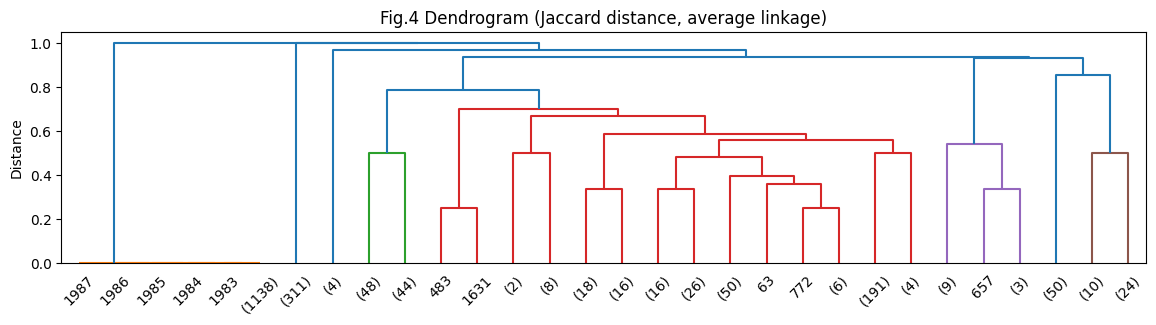

In [ ]:
# import needed libraries
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# encode booleans from True/False to 1/0
X = drugs_df[boolean_cols].astype(int).copy()

# compute distance with pdist() and condensed distance vector
distance = pdist(X, metric="jaccard")

# hierarchical clustering on distances
Z = linkage(distance, method="average")

# Plot
plt.figure(figsize=(14,3))
dendrogram(Z,
           truncate_mode="lastp", # show only the last p merged clusters to avoid error RecursionError: maximum recursion depth exceeded
           p=30,
           show_leaf_counts=True,
           no_labels=False)
plt.title("Fig.4 Dendrogram (Jaccard distance, average linkage)")
plt.ylabel("Distance")
plt.show()

**Creating Cluster Label**

After analyzing the dendrogram, n_clusters = 3 is chosen to create cluster label column. n_cluster = 4 was tried but eventually got abandoned as the total count in cluster 4 is far too small compared to the rest of the clusters, signaling 3 is the best number of clusters.



In [ ]:
n_clusters = 3
drugs_df["cluster_labels"] = fcluster(Z, n_clusters, criterion="maxclust").astype(str)
# Look at count of medicines in each cluster
drugs_df["cluster_labels"].value_counts()

,count
cluster_labels,
1,1143
3,534
2,311


**Refusal Rate in Each Cluster**

Refusal rates differ substantially across clusters. Generic medicines shows a near-zero refusal rate, while both standard medicines and those subject to complex regulatory pathways show higher refusal rates. This suggests that regulatory complexity is associated with elevated uncertainty in authorization outcomes.

In [ ]:
# Create refusal flag
drugs_df["is_refused"] = (
    drugs_df["authorisation_status"]
    .astype(str)
    .str.lower()
    .str.contains("refus")
)

# Calculate refusal rate for cluster
cluster_refusal = (
    drugs_df
    .groupby("cluster_labels")
    .agg(
        total_medicines=("cluster_labels", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
)
cluster_refusal

,cluster_labels,total_medicines,refused_medicines,refusal_rate
0,1,1143,39,0.034121
1,2,311,1,0.003215
2,3,534,17,0.031835


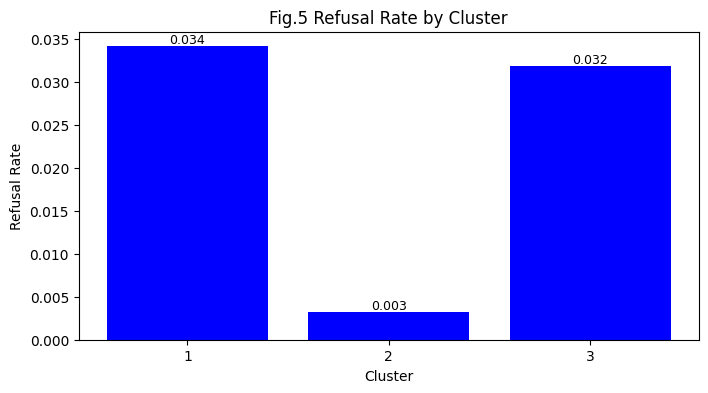

In [ ]:
# Visualizing refusal rate in each cluster
plt.figure(figsize=(8,4))
bars = plt.bar(
    cluster_refusal.index + 1,
    cluster_refusal["refusal_rate"],
    color = "blue"
)

plt.xticks((cluster_refusal.index+1).astype(int))

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}', # Format to 3 decimal places
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.5 Refusal Rate by Cluster")
plt.show()

### **Unstructured Methods**

#### **Exploring K-means**

In Milestone2, an unstructured analysis on `therapeutic_area` was conducted to uncover latent themes among medicines. The result display top words in 3 clusters; however, some words appear in multple clusters, showing the overlapping.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
# Keep only rows with therapeutic text
drugs_df_clean = drugs_df.dropna(subset=["therapeutic_area"]).copy()

# Identify refused drugs
drugs_df_clean["is_refused"] = drugs_df_clean["authorisation_status"].str.lower().str.contains("refus")

refused_df = drugs_df_clean[drugs_df_clean["is_refused"]].copy()

# Convert text in therapeutic_area into a numeric matrix to analyze patterns
vectorizer = TfidfVectorizer(stop_words="english",ngram_range=(1, 2),min_df=2,max_df=0.9)
X_refused = vectorizer.fit_transform(refused_df["therapeutic_area"])
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
refused_df["cluster"] = kmeans.fit_predict(X_refused)

# list items in each cluster
terms = np.array(vectorizer.get_feature_names_out())

for c in range(k):
    top_idx = kmeans.cluster_centers_[c].argsort()[-10:][::-1]
    print(f"\nCluster {c+1} – top therapeutic terms:")
    print(", ".join(terms[top_idx]))


Cluster 1 – top therapeutic terms:
neoplasms, breast, breast neoplasms, sclerosis, syndrome, tissue, myeloid acute, myeloid, major, lymphoma non

Cluster 2 – top therapeutic terms:
disease, tissue, sclerosis, non hodgkin, non, syndrome, myeloid acute, myeloid, major, lymphoma non

Cluster 3 – top therapeutic terms:
diseases, cell, fibromyalgia, disorders, syndrome, sclerosis, disease, tissue, lymphoma, non


In [ ]:
# Apply the same vectorizer + model to all drugs
X_all = vectorizer.transform(drugs_df_clean["therapeutic_area"])
drugs_df_clean["cluster"] = kmeans.predict(X_all) +1

cluster_refusal = (
    drugs_df_clean.groupby("cluster")
    .agg(
        total_medicines=("authorisation_status", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
    .sort_values("cluster", ascending=True)
)

cluster_refusal

,cluster,total_medicines,refused_medicines,refusal_rate
0,1,127,5,0.03937
1,2,106,2,0.018868
2,3,1470,46,0.031293


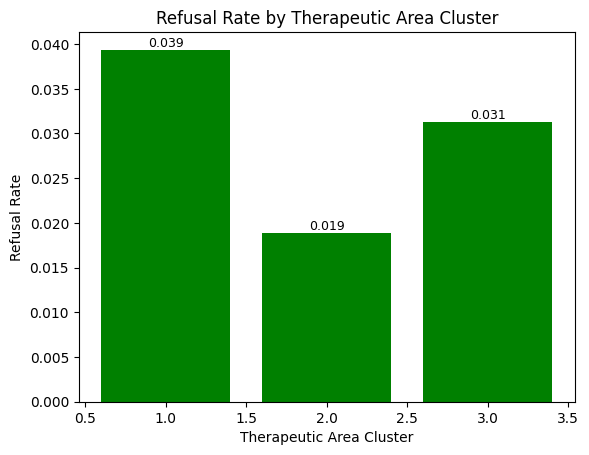

In [ ]:
# Refusal rate by each cluster
plt.figure()
bars = plt.bar(cluster_refusal["cluster"], cluster_refusal["refusal_rate"], color='green')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}', # Format to 3 decimal places
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Therapeutic Area Cluster")
plt.ylabel("Refusal Rate")
plt.title("Refusal Rate by Therapeutic Area Cluster")
plt.show()

A bar chart showing refusal rate by therapeutic cluster above shows that cluster2 has higher refusal rate compared to cluster1 and 3.

#### **Text Embedding**

The next analysis is to perform text embedding on `therapeutic_area` to capture any sementic meaning that the clustering method oversight. Specifically, to help answering subquestion: *are refusal therapeutic area-driven?* This analysis would further expend from the domain question to answer: *is refusal outcome structurally tied to therapeutic domain than regulatory pathways?*

Here, we perform text embedding to turn text in `therapeutic_area` into vectorized numbers in continous form.

In [ ]:
# Create text embeddings
from sentence_transformers import SentenceTransformer

# Load the pretrained Sentence Transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Text to encode
drugs_df["therapeutic_text"] = drugs_df["therapeutic_area"].astype(str)

# Calculate embeddings by calling model.encode()
# the progress bar can be opt out
embeddings = model.encode(drugs_df["therapeutic_text"].tolist())

X_embed = np.array(embeddings)

# Check total number of dimensions
X_embed.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1988, 384)

 After the embedding, we also calculate the embedding similarities.

In [ ]:
# Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
similarities

tensor([[1.0000, 0.2152, 0.6199,  ..., 0.0477, 0.2881, 0.1457],
        [0.2152, 1.0000, 0.2258,  ..., 0.1430, 0.2964, 0.1331],
        [0.6199, 0.2258, 1.0000,  ..., 0.0664, 0.2576, 0.0459],
        ...,
        [0.0477, 0.1430, 0.0664,  ..., 1.0000, 0.1666, 0.1921],
        [0.2881, 0.2964, 0.2576,  ..., 0.1666, 1.0000, 0.2722],
        [0.1457, 0.1331, 0.0459,  ..., 0.1921, 0.2722, 1.0000]])

There are 384 dimensions in the embedding. This is a large number of dimensions, so PCA (principal component analysis) is used to perform dimensionality reduction.

In [ ]:
# Check total number of dimensions
X_embed.shape

(1988, 384)

In [ ]:
# import package for PCA
from sklearn.decomposition import PCA

# create a model with 13 PCs
pca = PCA(n_components=13, random_state=42)
X_pca = pca.fit_transform(X_embed)

for i in range(13):
  drugs_df[f"thera_pc_{i}"] = X_pca[:, i]

In [ ]:
# View the 13 PCs
drugs_df[[f"thera_pc_{i}" for i in range(13)]].head()

,thera_pc_0,thera_pc_1,thera_pc_2,thera_pc_3,thera_pc_4,thera_pc_5,thera_pc_6,thera_pc_7,thera_pc_8,thera_pc_9,thera_pc_10,thera_pc_11,thera_pc_12
0,-0.320957,-0.163441,0.041394,-0.044807,0.105794,-0.161487,0.129230,-0.006165,-0.051888,0.198092,-0.107588,-0.056263,0.112964
1,-0.186764,0.100155,0.015922,-0.148274,0.104386,0.064976,-0.047150,-0.089948,0.138252,0.091660,0.094101,0.136086,0.080396
2,-0.288580,-0.001122,0.044123,-0.028649,0.071817,-0.061405,0.119602,-0.107974,0.087341,0.180216,-0.141137,0.053970,0.051745
3,-0.157369,-0.198198,-0.436351,-0.082729,-0.031704,0.049644,0.065092,0.042508,-0.148624,0.026271,0.192102,-0.072186,0.144085
4,-0.228236,-0.088960,-0.018518,0.115611,0.068610,-0.247825,-0.489173,-0.161575,0.213584,0.140983,-0.028260,0.020464,0.024625


In [ ]:
# Check how much variance PCs explain
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.16919029 0.06479827 0.05451741 0.04443092 0.03378949 0.03059513
 0.02894937 0.02643789 0.02308032 0.02170931 0.01991553 0.01765737
 0.01716455]
0.55223584


With 13 PCs, the components capture 55% of total embedding variance. Since embedding space is high dimensional, it is reasonable for the 13 PCs to capture only 55%. Increaseing number of PCs would increase the variance captured but would introduce noise and potentially overfitting. So let's decide 13 PCs is enough to prevent the issues and maintain statistical reliability.

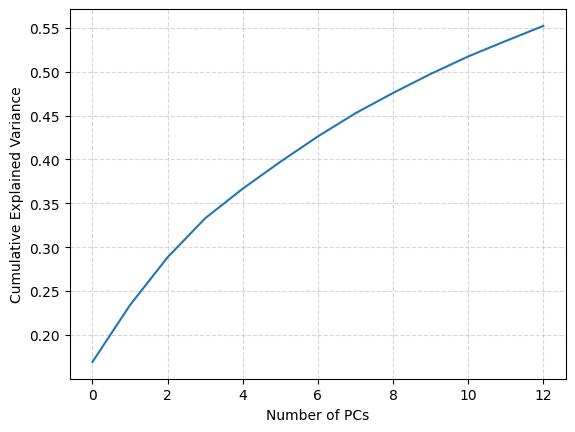

In [ ]:
# Scree plot showing explained variance by different number of PCs
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Since we are interested in examining if therapeutic_area semantic stucture assocaite with refusal outcome, let's first convert the authorisation_status into binary variable and perform ligistic regression to check if it is statistically significant.

Note that the assocaition rules mining was attempted but eventually abandoned because it works on categorical variables and the embedding PCs are ventorized in a continuous numerical type.

In [ ]:
# Analyze influence of therapeutic embedding alone
# Run logistic regress because it is a binary classification
import statsmodels.formula.api as sm

# Create binary outcome
drugs_df["refused_binary"] = (
    drugs_df["authorisation_status"]
    .str.lower()
    .eq("refused")
    .dropna()
    .astype(int)
)

reg = sm.logit(
    'refused_binary ~ thera_pc_0 + thera_pc_1 + thera_pc_2 + thera_pc_3 + \
     thera_pc_4 + thera_pc_5 + thera_pc_6 + thera_pc_7 + thera_pc_8 + thera_pc_9 + \
     thera_pc_10 + thera_pc_11 + thera_pc_12',
    data=drugs_df
).fit()

print(reg.summary())

Optimization terminated successfully.
         Current function value: 0.122225
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         refused_binary   No. Observations:                 1987
Model:                          Logit   Df Residuals:                     1973
Method:                           MLE   Df Model:                           13
Date:                Mon, 23 Feb 2026   Pseudo R-squ.:                 0.06086
Time:                        20:13:32   Log-Likelihood:                -242.86
converged:                       True   LL-Null:                       -258.60
Covariance Type:            nonrobust   LLR p-value:                  0.002870
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -3.8164      0.175    -21.809      0.000      -4.159      -3.473
thera_pc_0     -0.3409    

From the logit regression above, important results are shown.

LLR p-value of 0.006 shows the whole model is statistically significant but with Pseudo R-square at 0.06, its explanatory power is modest.

Interestingly, among all PCs, `thera_pc_4` displays a clear significant with p-value < 0.001 (means statistically significant at 1% confidence interval). This means that variation along this specific therapeutic sementic direction is strongly assocaited with refusal likelihood. `thera_pc_7` is also statistically significant but at the 10% confidence interval, signaling weaker evidence and higher chance of false positive. Additionally, the remaining PCs are not significant. This suggests that refusal outcome is not broadly therapeutic area-driven across semantic dimensions but rather at specific region (thera_pc_4).

- LLR p-value tests whether the logistric regression model as a whole is statistically significant.
- Pseudo R-square is a measure of model fit for models that are estimated using maximum likelyhood (like logistric regression!). Not using regular R-square because it's for continuous outcomes and it minimizes square error.

To better visualize, scatterplots below shows the relationship between PCs and the predicted probability of refusal from the logstric regression model.

As you can see, there is a positive relationship with thera_pc_4. This means that medicines with higher thera_pc_4 values tends to have a higher predicted refusal. In contrast, `thera_pc_7` shows no clear relationship.

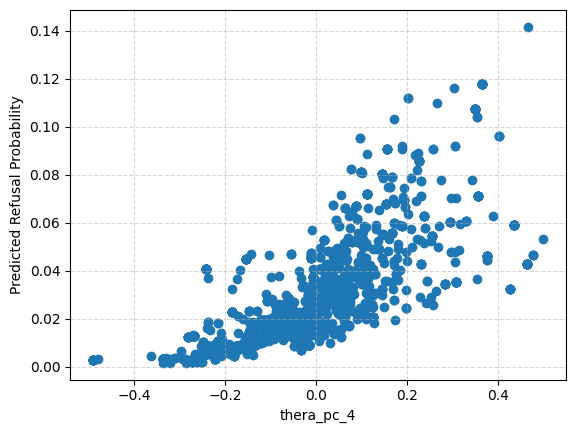

In [ ]:
# Predict for all rows in drugs_df (rows with missing PCs will become NaN)
drugs_df["pred_prob"] = reg.predict(drugs_df)

plt.scatter(drugs_df["thera_pc_4"], drugs_df["pred_prob"])
plt.xlabel("thera_pc_4")
plt.ylabel("Predicted Refusal Probability")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

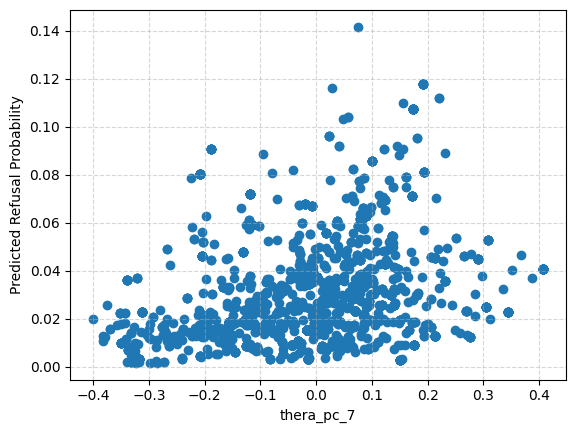

In [ ]:
# Predict for all rows in drugs_df (rows with missing PCs will become NaN)
drugs_df["pred_prob"] = reg.predict(drugs_df)

plt.scatter(drugs_df["thera_pc_7"], drugs_df["pred_prob"])
plt.xlabel("thera_pc_7")
plt.ylabel("Predicted Refusal Probability")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

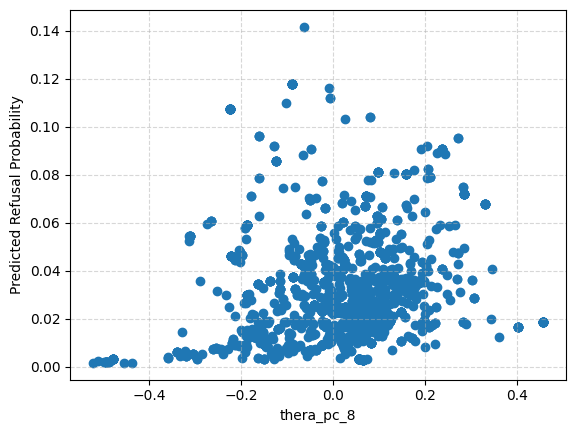

In [ ]:
drugs_df["pred_prob"] = reg.predict(drugs_df)

plt.scatter(drugs_df["thera_pc_8"], drugs_df["pred_prob"])
plt.xlabel("thera_pc_8")
plt.ylabel("Predicted Refusal Probability")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## **Key Findings**


The findings from this analysis carry important business implications for pharmaceutical companies navigating the regulatory approval process.
1. First, the most important insight is that medicines that never enter a revision stage are significantly more likely to be refused. This suggests that early disengagement or failure to respond to regulatory feedback may be a strong risk factor. Therefore, companies should interpret the revision stage as a sign of ongoing viability and active regulatory dialogue. Investing in responsive regulatory affairs teams, structured feedback mechanisms, and improved development processes may materially reduce refusal risk.
2. Second, the analysis suggests that refusal outcomes are more closely tied to regulatory pathway dynamics than to therapeutic domain alone. Deeper modeling shows that the therapeutic domain provides only modest explanatory power. This indicates that refusal is not broadly driven by belonging to a specific clinical area. Instead, how a medicine navigates the regulatory framework (i.e. pathway selection, evidence preparation, and revision cycles) appears to play a more meaningful role. For pharmaceutical companies, this highlights the strategic importance of regulatory positioning and pathway planning. Competitive advantage may therefore lie less in selecting a “low-risk” therapeutic area and more in designing a robust clinical development plan and aligning early with regulatory expectations.
3. Lastly, the embedding analysis revealed that certain specific semantic therapeutic profiles are associated with elevated refusal likelihood, even though the overall effect remains modest. This implies that risk is not evenly distributed but concentrated in narrower semantic regions. In such cases, companies can use this analysis to identify which projects may require stronger evidence, more careful study design, or earlier engagement with regulators.

Overall, the central business implication is that refusal risk is primarily process-driven rather than category-driven. Companies that strengthen regulatory engagement, prioritize evidence quality, and proactively manage pathway strategy are more likely to improve approval outcomes than those focusing solely on therapeutic domain selection.
